# In-class Assignment 1.2

Week 1 Wednesday

#### &#x2705; Stephanie Poole, Stefania Feliciano, Hanna Speckman, Cy Acosta

---

## Part 1: Set up a GitHub repository together

In the pre-class assignment, you created a directory on your JupyterHub where you initialized a repository and linked it to the remote Github class wiki repository. In doing so, you practiced some terminal commands for navigating directories, issuing `git` commands, and making changes to files through the command-line interface (CLI).

Today, you'll build on those skills to set up a system where you can collaborate on coding assignments with your group members.

### One group member only: Go to GitHub and create a repository for your group

At the top of the page, click the plus icon and then "New Repository". This will be the repository in which the whole group will collaborate for the next three weeks. Decide on a short but memorable name for the repo. For now, ignore the configuration options section. 

<div class="alert alert-block alert-info">
<b>Note:</b> By default, Github makes repositories <b>public</b>. Do not put any information in a public repository that you do not want other people to see, including private keys, personal emails, or anything you do not want linked to yourself.</div>

Once you've created the repository, add everyone in your group as collaborators to your repo. Also, add the faculty instructor and grad TA.

### Every group member: Make a local JupyterHub repo, and link it to the GitHub repo

Hint: you've done this before!

Open up the JuypterHub Terminal, and try to achieve this task using only terminal commands -- everything you need to do this is from the PCA. More detailed steps are listed below.

Here are some commands you'll need:
- `git init`
- `git remote add origin git@github.com:<user>/<repository>.git`
- `git pull --set-upstream origin main`
    - *Note: You are recommended to use `pull` instead of `push` for this setup because you might want to "pull" existing files that your group members created from the remote GitHub repo into your local JupyterHub repo.*

You can use these steps to guide your setup:
1. Make a new directory in your JupyterHub, and initialize a repository in that directory.
2. Connect your local (JupyterHub) repo to the SSH URL of the remote (GitHub) repo.
3. Set the remote repo as the upstream to your local repo through a `pull` command.

### Every group member: Add a file introducing yourself to the GitHub repo

Consider using these commands while you are working on this:
- `git status`
- `git add <filename>`
- `git commit -m "write a message in quotes"`
- **`git pull --rebase`**
- `git push`

(If you get any messages about "divergent branches" or "merge conflicts" while you are working on this part, ask your group members or your group instructor for assistance)

1. Create a file in your local directory.
2. Add the file to your local repo.
3. Commit the change using a descriptive message.
4. Push the change to the remote repo.

---

## Part 2: Create a group agreement

To guide how you want to collaborate together in class, discuss your collaboration goals together and write up an agreement. Consider reading through the [in-class assessment guide](https://canvas.oregonstate.edu/courses/2050398/files/117570531) together as well.

Discuss these questions together, and **write up notes in a separate file that you will share on your group repo.** You can choose to designate one person as a notetaker, who can push their notes onto the shared repo after your discussion.

If you are up for a git challenge, you could also choose to *collaborate* on one document into which multiple group members can edit and commit/push changes.

In your group agreement, complete these prompts:

> **Our goals as a group are...**
> 
> **We all agree to the following expectations for group work...**
> 
> **If we use generative AI during class, we agree to...**

Here are some questions to guide your discussion.

For each group member: 
- What parts of participation seem like they will be challenging for you? 
- What is a goal you can set related to collaboration or modeling that you can work towards? 
- How can your group members help support you or keep you accountable to this goal? 

As a group: 
- What expectations do you have for one another to function effectively as a group? 
- How will you communicate with one another about the group project? (even if someone has to miss class unexpectedly) 
- What is the role of respect, cooperation, mutual trust, and openness in this group? 
- If group members disagree on how to approach the group project, how will that conflict be handled? 

Using generative AI:
- What has your experience been using GenAI in past courses?
- Should you use GenAI at all during group work in this course?
- If/when you use it, what expectations do you want to set for how to use it and how to document your work?

---

## Part 3: Modeling magnetization at different temperatures

Recall from Monday's slides, the steps of the modeling cycle:
1. Pose a new question about a real-world physics phenomenon
2. Gather your resources + make assumptions to create a simplified "model-world" phenomenon.
3. Create/refine a computational model of the simplified phenomenon.
4. Test your model to see what you can learn about the original question.

&#x2705; Identify all four steps of the modeling cycle to the existing code below, adding markdown chunks with narrative text to explain them.

&#x2705; As you go, also add comments to the code to explain most of the lines of code. You can skip lines that your  already addressed earlier (for example, you don't have to explain `plt.show()` twice).

&#x2705; At the very, pose new questions that you could investigate about this phenomenon.

### How hot can a magnet get until it's not a magnet anymore?

Starting from a mean field theory equation, which basically means an equation that models the magnetization of a material based on the mean behavior of its individual particles.

$$ M = \tanh \left(\frac{MnJ}{k_B T}\right) $$

$M$ is magnetization, and $T$ is temperature. The other values can be considered constants: $k_B$ is Boltzmann constant, $n$ is number of particles, $J$ can be modeled as a constant of the material. 

Let's begin by looking for a graphical solution. We define $x=\frac{nJ}{k_b T}$, so that $x \gg 1$ corresponds to low temperature while $x \ll 1$ corresponds to high temperature.

In [1]:
import numpy as np

M = np.linspace(0,1.5,1000)

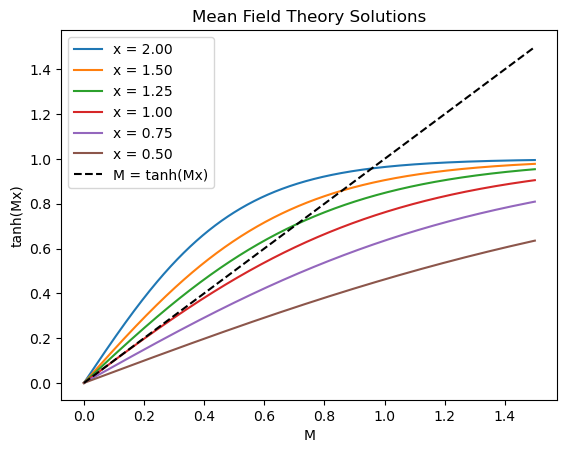

In [3]:
import matplotlib.pyplot as plt

x_vals = [2.0, 1.5, 1.25, 1.0, 0.75, 0.5]

for x in x_vals:
    plt.plot(M, np.tanh(M * x), label="x = %0.2f" % x)
    
plt.plot(M, M, color="black", linestyle="--", label="M = tanh(Mx)")

plt.xlabel("M")
plt.ylabel("tanh(Mx)")
plt.legend()
plt.title("Mean Field Theory Solutions")
plt.show()

No matter what we set $x$ to, there seems to generally be a solution for $M$ between 0 and 1. 

So let's solve for it...

In [4]:
def mean_field_eqn(mag, x_temp):
    return mag - np.tanh(mag * x_temp)

In [5]:
from scipy.optimize import fsolve

N = 10000

x = np.linspace(0.5, 100, N)
Mx = np.empty(N)

for i in range(N):
    sol_i = fsolve(mean_field_eqn, 1.0, args=(x[i]))
    Mx[i] = sol_i[0]

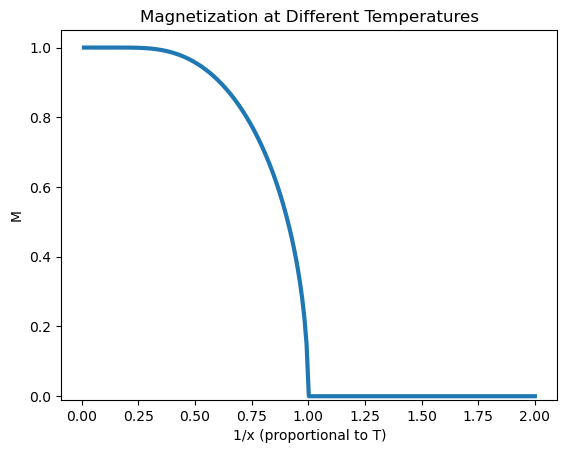

In [17]:
plt.plot(1.0 / x, Mx, linewidth=3)

plt.xlabel("1/x (proportional to T)")
plt.ylabel("M")
plt.ylim(-0.01,1.05)
plt.title("Magnetization at Different Temperatures")
plt.show()